In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### **Ejercicio N°6**
Utilizando el dataset `partos2022.txt`, el cual contiene información sobre los partos atendidos en el 2022 en el Hospital Roque Sáenz Peña (HRSP) y la Maternidad Martin (MR), efectores municipales de la ciudad:

In [10]:
partos = pd.read_csv('./datasets/partos2022.txt', sep='\t', encoding='latin1')
partos

,año,mes,efector,idParto,idMama,rango_edad_mama,n_hijo,lugar_parto,terminacion_parto,edad_gestacional,peso_bb,sexo,nacimiento
0,2022,8,HRSP,1,951,35 a 39 años,1,Quirófano,Cesárea,32 a 37 sem,2980,M,Vivo
1,2022,1,HRSP,2,3437,25 a 29 años,1,Quirófano,Cesárea,38 a 41 sem,4215,F,Vivo
2,2022,1,HRSP,3,3411,20 a 24 años,1,Sala de partos,Normal,38 a 41 sem,3920,M,Vivo
3,2022,1,HRSP,4,528,25 a 29 años,1,Sala de partos,Normal,38 a 41 sem,3950,M,Vivo
4,2022,1,HRSP,5,2030,30 a 34 años,1,Sala de partos,Normal,38 a 41 sem,2650,M,Vivo
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4592,2022,12,MM,3268,2618,20 a 24 años,1,Sala de partos,Normal,38 a 41 sem,3490,F,Vivo
4593,2022,12,MM,3269,3468,20 a 24 años,1,Quirófano,Cesárea,32 a 37 sem,2390,M,Muerto
4594,2022,12,MM,3270,4098,15 a 19 años,1,Sala de partos,Normal,38 a 41 sem,3000,M,Vivo
4595,2022,12,MM,3271,2075,40 a 44 años,1,Quirófano,Cesárea,38 a 41 sem,3480,F,Vivo


In [11]:
partos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4597 entries, 0 to 4596
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   año                4597 non-null   int64 
 1   mes                4597 non-null   int64 
 2   efector            4597 non-null   object
 3   idParto            4597 non-null   int64 
 4   idMama             4597 non-null   int64 
 5   rango_edad_mama    4577 non-null   object
 6   n_hijo             4597 non-null   int64 
 7   lugar_parto        4597 non-null   object
 8   terminacion_parto  4597 non-null   object
 9   edad_gestacional   4597 non-null   object
 10  peso_bb            4597 non-null   int64 
 11  sexo               4597 non-null   object
 12  nacimiento         4597 non-null   object
dtypes: int64(6), object(7)
memory usage: 467.0+ KB


1. Indique los meses en los que se registró la mayor y la menor cantidad de partos atendidos. ¿Qué porcentajes del total de partos atendidos en el año representan?

In [24]:
partos['mes'].value_counts().sort_values(ascending=False)

mes
4     484
3     482
7     410
2     409
8     399
1     392
12    375
11    362
10    355
5     318
9     315
6     296
Name: count, dtype: int64

In [25]:
mes_max=partos['mes'].value_counts().idxmax()
max=partos['mes'].value_counts().max()
print(f'El mes con mayor cantidad de partos fue {mes_max} con {max} partos')

El mes con mayor cantidad de partos fue 4 con 484 partos


In [26]:
mes_min=partos['mes'].value_counts().idxmin()
min=partos['mes'].value_counts().min()
print(f'El mes con mayor cantidad de partos fue {mes_min} con {min} partos')

El mes con mayor cantidad de partos fue 6 con 296 partos


2. Represente gráficamente la distribución del número de partos atendidos en el 2022 según el efector. ¿Qué puede decir acerca de la institución en la que tuvieron lugar los partos?

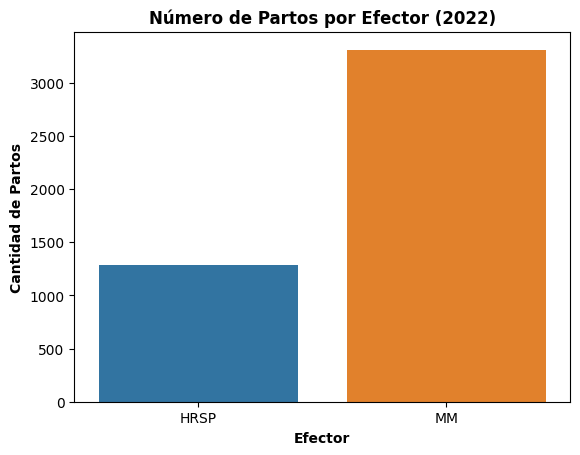

In [29]:
sns.countplot(data=partos,x='efector',hue='efector')
plt.title('Número de Partos por Efector (2022)', fontweight='bold')
plt.xlabel('Efector', fontweight='bold')
plt.ylabel('Cantidad de Partos', fontweight='bold')
plt.show()

3. Realice un gráfico que permita comparar la distribución del peso de los recién nacidos entre las distintas categorías de la edad gestacional. ¿Qué observa?

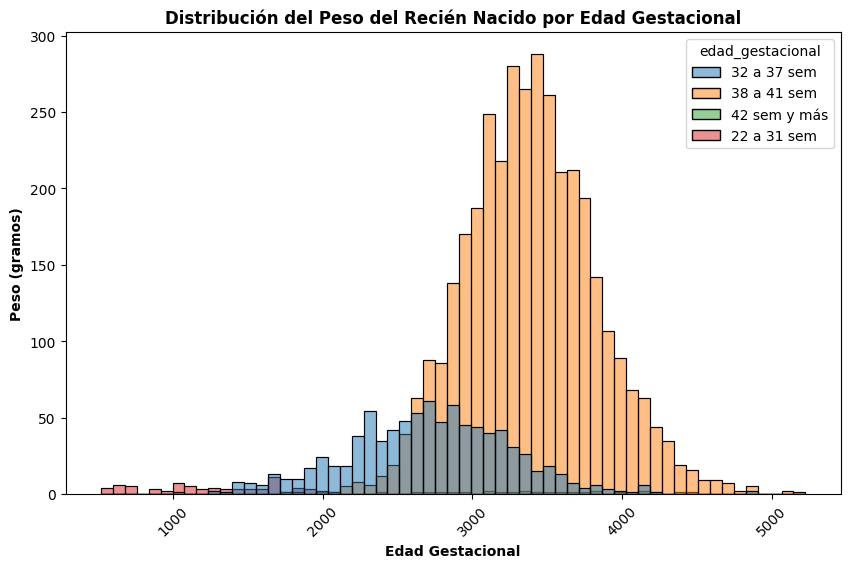

In [35]:
plt.figure(figsize=(10, 6))
sns.histplot(data=partos,x='peso_bb',hue='edad_gestacional')
#sns.boxplot(data=df_partos, x='edad_gestacional', y='peso_bb', palette='Set2')
plt.title('Distribución del Peso del Recién Nacido por Edad Gestacional', fontweight='bold')
plt.xlabel('Edad Gestacional', fontweight='bold')
plt.ylabel('Peso (gramos)', fontweight='bold')
plt.xticks(rotation=45)
plt.show()

4. Realice una descripción general de las variables **rango etario de la madre** (**`rango_edad_mama`**) y **tipo de parto** (**`terminacion_parto`**) que incluya: tipo de variables, valores que toman, distribución de cada una en la muestra y presencia de datos faltantes.

In [37]:
partos['rango_edad_mama'].value_counts()

rango_edad_mama
20 a 24 años     1345
25 a 29 años     1232
30 a 34 años      888
15 a 19 años      560
35 a 39 años      424
40 a 44 años      117
10 a 14 años        7
45 a 49 años        3
50 años y más       1
Name: count, dtype: int64

In [39]:
partos['rango_edad_mama'].isnull().sum()

np.int64(20)

rango_edad_mama

    * es una variable cualitativa ordinal

    * toma valores de intervalos de 4 años hasta los 50 años y mas

    * La mayor parte de la distribucion se concentra en los rangos de 20 a 24 años y 25 a 29 años

    * Hay 20 nulls

In [40]:
partos['terminacion_parto'].value_counts()

terminacion_parto
Normal     3169
Cesárea    1364
Fórceps      54
Otros        10
Name: count, dtype: int64

In [41]:
partos['terminacion_parto'].isnull().sum()

np.int64(0)

terminacion_parto

    * es una variable cualitativa nominal

    * toma valores 'Normal','Cesarea','Forceps','Otros'.

    * La mayor parte de la distribucion se concentra en los valores 'Normal' y 'Cesarea'
    
    * No hay nulls

5. Recategorice la variable **`rango_edad_mama`** de la siguiente manera: 10-19 años, 20-29 años, 30-39 años y 40 años o más.


In [ ]:
mapeo_edades={
    '10 a 14 años':'10-19 años',
    '15 a 19 años':'10-19 años',
    '20 a 24 años':'20-29 años',
    '25 a 29 años':'20-29 años',
    '30 a 34 años':'30-39 años',
    '35 a 39 años':'30-39 años',       
    '40 a 44 años':'40 años o más',
    '45 a 49 años':'40 años o más',
    '50 años y más':'40 años o más'}

partos['rango_edad_mama']=partos['rango_edad_mama'].replace(mapeo_edades)


In [44]:
partos['rango_edad_mama'].value_counts()

rango_edad_mama
20-29 años       2577
30-39 años       1312
10-19 años        567
40 años o más     121
Name: count, dtype: int64

6. Recategorice la variable **`terminacion_parto`** de forma tal que la categoría **Fórceps** se encuentre comprendida dentro de **Otros**.

In [45]:
partos['terminacion_parto']=partos['terminacion_parto'].replace({'Fórceps':'Otros'})

In [46]:
partos['terminacion_parto'].value_counts()

terminacion_parto
Normal     3169
Cesárea    1364
Otros        64
Name: count, dtype: int64

7. Construya un gráfico de barras paralelas que muestre la distribución general del tipo de parto (Cesárea/Normal/Otros) según el rango etario de la madre, en el que los porcentajes de cada categoría se encuentren calculados **sobre el total general de partos atendidos para los que se cuenta con información sobre la edad de la madre (n = 4577)**.
8. Construya un gráfico de barras paralelas que muestre la distribución del tipo de parto según el rango etario de la madre, en el que los porcentajes de cada categoría se encuentren calculados **sobre el total de partos atendidos para cada uno de estos grupos etarios**.

In [49]:
#dropna para quedar con 4577
partos=partos.dropna(subset=['rango_edad_mama'])
tabla_frecuencia=pd.crosstab(partos['rango_edad_mama'],partos['terminacion_parto'])
tabla_frecuencia

terminacion_parto,Cesárea,Normal,Otros
rango_edad_mama,,,
10-19 años,129,427,11
20-29 años,747,1786,44
30-39 años,440,867,5
40 años o más,41,77,3


In [52]:
tabla_totales=round((tabla_frecuencia/len(partos))*100,2)
tabla_totales

terminacion_parto,Cesárea,Normal,Otros
rango_edad_mama,,,
10-19 años,2.82,9.33,0.24
20-29 años,16.32,39.02,0.96
30-39 años,9.61,18.94,0.11
40 años o más,0.90,1.68,0.07


In [ ]:
tabla_relativos = round(tabla_frecuencia.div(tabla_frecuencia.sum(axis=1), axis=0)*100,2) 
#tabla_frecuencias.sum(axis=1) suma horizontalmente las columnas
# .div( ... , axis=0) Toma mi tabla original y divídela por los totales que calculé en el Paso 1
# El parámetro axis=0 es fundamental. Le dice a Pandas: "Alinea los datos por el índice (las filas)". Es decir, toma todos los valores de la fila "10 a 19 años" 
# y divídelos por el total de "10 a 19 años".

tabla_relativos

terminacion_parto,Cesárea,Normal,Otros
rango_edad_mama,,,
10-19 años,22.75,75.31,1.94
20-29 años,28.99,69.31,1.71
30-39 años,33.54,66.08,0.38
40 años o más,33.88,63.64,2.48


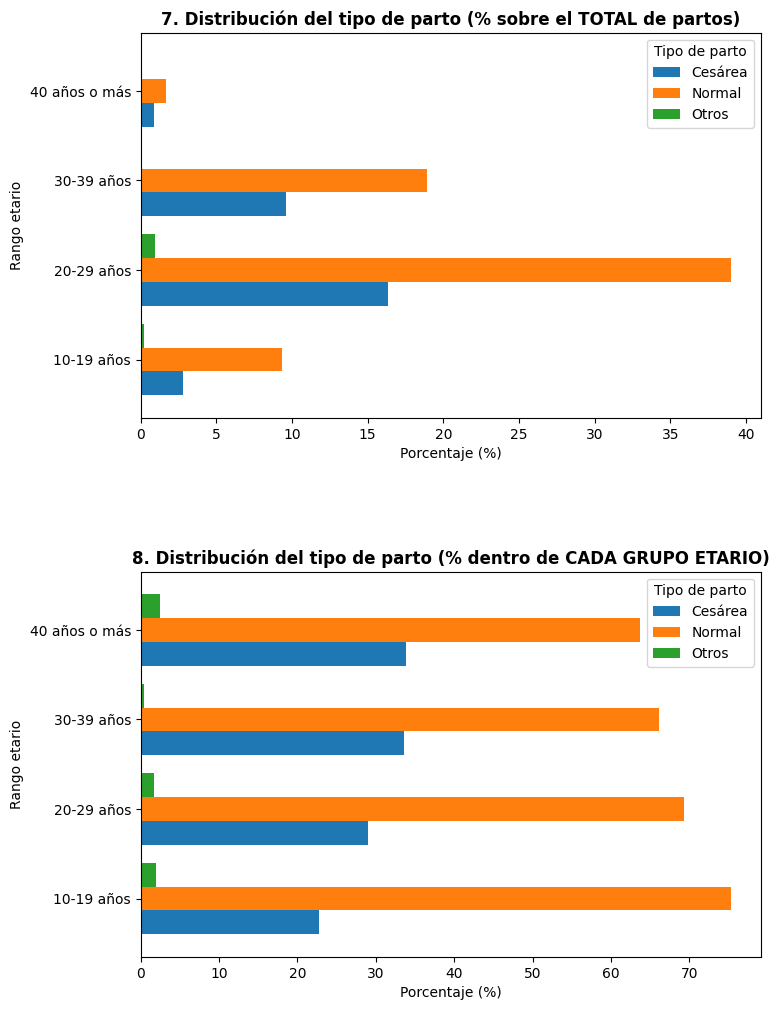

In [58]:
# Configuración de los gráficos
fig, axes = plt.subplots(2, 1, figsize=(8,12))
plt.subplots_adjust(hspace=0.4)

# Gráfico Ítem 7
tabla_totales.plot.barh(ax=axes[0], width=0.8)
axes[0].set_title('7. Distribución del tipo de parto (% sobre el TOTAL de partos)', fontweight='bold')
axes[0].set_xlabel('Porcentaje (%)')
axes[0].set_ylabel('Rango etario')
axes[0].legend(title='Tipo de parto', bbox_to_anchor=(1, 1))

# Gráfico Ítem 8
tabla_relativos.plot.barh(ax=axes[1], width=0.8)
axes[1].set_title('8. Distribución del tipo de parto (% dentro de CADA GRUPO ETARIO)', fontweight='bold')
axes[1].set_xlabel('Porcentaje (%)')
axes[1].set_ylabel('Rango etario')
axes[1].legend(title='Tipo de parto', bbox_to_anchor=(1, 1))

plt.show()

9. Compare los gráficos realizados en el ítem anterior. ¿Qué tipo de información brinda cada uno?

    * En el grafico de arriba se ve el comportamiento global, mientras que en el de abajo se ve el comportamiento propio de cada grupo etario
    
10. **PARA PENSAR:** ¿Cuál de los gráficos anteriores le permite analizar si la edad de la madre influye en la probabilidad de recurrir a una cesárea como método de parto? ¿Qué observa?
    
    * El segundo grafico ya que permite observar como aumenta el porcentaje de cesarea a mayor edad de embarazo y a su vez como van disminuyendo los partos normales